# Multilayer Perceptron (MLP) for Multiclass Credit Risk Prediction

## Goal
In this notebook we build a **neural network classifier** to predict a borrower’s **credit risk grade** based only on information available **before (or at) loan issuance**.

We use the LendingClub target label:
- `grade` ∈ {A, B, C, D, E, F, G} (A = lower risk, G = higher risk)
- encoded as `grade_idx` ∈ {0,1,2,3,4,5,6}

For this MLP experiment, the labels are also grouped into **3 buckets** (`bucket_idx` ∈ {0,1,2}) to simplify the prediction task.

## Dataset
Splits (balanced):
- **Train:** (59619, 24)  -> 8,517 samples per grade
- **Dev:**   (12775, 24)
- **Test:**  (12782, 24)

Each split contains:
- **Labels (2):** `grade`, `grade_idx`
- **Features (22):**
  - Categorical: `purpose`, `home_ownership`, `verification_status`, `addr_state`
  - Numeric: `loan_amnt`, `term`, `emp_length`, `annual_inc`, `dti`, `delinq_2yrs`,
    `inq_last_6mths`, `open_acc`, `total_acc`, `pub_rec`, `revol_bal`, `revol_util`,
    `collections_12_mths_ex_med`, `acc_now_delinq`, `pub_rec_bankruptcies`, `tax_liens`,
    `credit_history_months`, `fico_avg`

Bucket class counts:
- Train: [17034, 17034, 25551]
- Dev:   [3650, 3650, 5475]
- Test:  [3652, 3652, 5478]

## Preprocessing
Neural networks need numeric tensors, so we do:

1. **Separate labels from features**
   - `y` is the target (bucket label for this run)
   - `X` contains only input features

2. **Handle skewed numeric features**
   - On TRAIN, compute skewness and apply a log transform to highly skewed columns  
   - Threshold used: skewness > 1.5  
   - Applied `log1p(x) = log(1 + x)` to:
     `annual_inc, revol_bal, dti, acc_now_delinq, tax_liens, collections_12_mths_ex_med,
      delinq_2yrs, pub_rec, pub_rec_bankruptcies, inq_last_6mths`

3. **Standardize numeric features (TRAIN stats only)**
   - mean = 0, std = 1 (fit on train, reused on dev/test)

4. **One-hot encode categorical features**
   - After encoding, the feature dimension becomes:
     - `X_train`: (59619, 41)
     - `X_dev`  : (12775, 41)
     - `X_test` : (12782, 41)
   - We also ensure dev/test columns match train exactly.

## Model
We use a feed-forward MLP with ReLU + dropout:

- 41 -> 512 -> 256 -> 128 -> 3
- Dropout = 0.1 between hidden layers

## Training setup
Loss and optimizer:
- `CrossEntropyLoss` (multiclass)
- SGD with momentum:
  - learning rate = 0.02
  - momentum = 0.9
  - weight decay = 1e-5
- epochs = 20

Each epoch we record train/dev/test **loss** and **accuracy**.

## Evaluation
We evaluate on Train, Dev, and Test each epoch and also inspect a confusion matrix.
Final epoch results (Epoch 20):
- Train acc ≈ 0.7066
- Dev acc   ≈ 0.6871
- Test acc  ≈ 0.6823

Confusion matrix (Test):
$$
\begin{array}{c|ccc}
\text{True}\backslash\text{Pred} & 0 & 1 & 2 \\
\hline
0 & 2854 & 683  & 115 \\
1 & 869  & 1655 & 1128 \\
2 & 221  & 1045 & 4212 \\
\end{array}
$$

This gives a quick view of which buckets the model confuses most often.


Import data/plotting + PyTorch training utilities, set seeds for reproducibility, then pick GPU if available (else CPU) and print the device.


In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Mount Google Drive + locate CSVs

In [3]:
from google.colab import drive
drive.mount("/content/drive")

DATA_ROOT = Path("/content/drive/MyDrive/ML Project/Data")
TRAIN_DIR = DATA_ROOT / "Train"
TEST_DIR  = DATA_ROOT / "Test"

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TEST_DIR exists :", TEST_DIR.exists())

train_csv = TRAIN_DIR / "train.csv"
dev_csv   = TRAIN_DIR / "dev.csv"
test_csv  = TEST_DIR  / "test.csv"

print("\nTrain CSV:", train_csv, "exists:", train_csv.exists())
print("Dev CSV  :", dev_csv, "exists:", dev_csv.exists())
print("Test CSV :", test_csv, "exists:", test_csv.exists())


Mounted at /content/drive
DATA_ROOT exists: True
TRAIN_DIR exists: True
TEST_DIR exists : True

Train CSV: /content/drive/MyDrive/ML Project/Data/Train/train.csv exists: True
Dev CSV  : /content/drive/MyDrive/ML Project/Data/Train/dev.csv exists: True
Test CSV : /content/drive/MyDrive/ML Project/Data/Test/test.csv exists: True


## Load datasets

In [4]:
train_df = pd.read_csv(train_csv)
dev_df   = pd.read_csv(dev_csv)
test_df  = pd.read_csv(test_csv)

print("Train shape:", train_df.shape)
print("Dev shape  :", dev_df.shape)
print("Test shape :", test_df.shape)

print("\nColumns:", list(train_df.columns))
print("\nLabel counts (train):")
print(train_df["grade"].value_counts().sort_index())


Train shape: (59619, 24)
Dev shape  : (12775, 24)
Test shape : (12782, 24)

Columns: ['grade', 'grade_idx', 'purpose', 'home_ownership', 'verification_status', 'addr_state', 'loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']

Label counts (train):
grade
A    8517
B    8517
C    8517
D    8517
E    8517
F    8517
G    8517
Name: count, dtype: int64


## Bucket labels (3-class target)

Convert `grade_idx` (A=0 … G=6) into `bucket_idx`:
- 0 = low (A,B)
- 1 = mid (C,D)
- 2 = high (E,F,G)

Add `bucket_idx` to train/dev/test and print class counts per split.


In [5]:
def grade_to_bucket_from_idx(grade_idx: pd.Series) -> pd.Series:
    # A=0, B=1 -> low
    # C=2, D=3 -> medium
    # E=4, F=5, G=6 -> high
    return pd.cut(
        grade_idx,
        bins=[-1, 1, 3, 6],
        labels=[0, 1, 2]
    ).astype(int)

for df, name in [(train_df, "train"), (dev_df, "dev"), (test_df, "test")]:
    df["bucket_idx"] = grade_to_bucket_from_idx(df["grade_idx"])
    print(f"{name} bucket counts:\n", df["bucket_idx"].value_counts().sort_index(), "\n")


train bucket counts:
 bucket_idx
0    17034
1    17034
2    25551
Name: count, dtype: int64 

dev bucket counts:
 bucket_idx
0    3650
1    3650
2    5475
Name: count, dtype: int64 

test bucket counts:
 bucket_idx
0    3652
1    3652
2    5478
Name: count, dtype: int64 



Normalization

## Build MLP-ready features (standardize + one-hot)

- Target label: `bucket_idx` (3 classes); drop label columns: `grade`, `grade_idx`, `bucket_idx`
- Use only these categoricals (we **exclude `addr_state`**): `purpose`, `home_ownership`, `verification_status`
- Auto-detect numeric columns from the remaining features

`preprocess()` does:
- Split `X`/`y` for train/dev/test
- Keep only selected numeric + categorical columns
- Standardize numeric features using **TRAIN mean/std only**
- One-hot encode categorical features
- Reindex dev/test to match train’s one-hot columns

Finally prints the final `X`/`y` shapes after encoding.


In [6]:
LABEL_COL = "bucket_idx"
DROP_COLS = ["grade", "grade_idx", "bucket_idx"]

# REMOVE addr_state
categorical_cols = ["purpose", "home_ownership", "verification_status"]

# Features (exclude labels)
X_train_raw = train_df.drop(columns=DROP_COLS)

# Numeric columns: those not categorical AND actually numeric dtype
numeric_cols = [
    c for c in X_train_raw.columns
    if (c not in categorical_cols) and pd.api.types.is_numeric_dtype(X_train_raw[c])
]

print("Categorical:", categorical_cols)
print("Numeric    :", numeric_cols)
print("Total raw feature cols:", X_train_raw.shape[1])

def preprocess(train_df, dev_df, test_df, categorical_cols, numeric_cols):
    y_train = train_df[LABEL_COL].to_numpy()
    y_dev   = dev_df[LABEL_COL].to_numpy()
    y_test  = test_df[LABEL_COL].to_numpy()

    X_train = train_df.drop(columns=DROP_COLS).copy()
    X_dev   = dev_df.drop(columns=DROP_COLS).copy()
    X_test  = test_df.drop(columns=DROP_COLS).copy()

    # Keep only numeric + categorical columns we intend to use
    keep_cols = numeric_cols + categorical_cols
    X_train = X_train[keep_cols]
    X_dev   = X_dev[keep_cols]
    X_test  = X_test[keep_cols]

    # Standardize numeric cols using TRAIN stats only
    mu = X_train[numeric_cols].mean()
    sigma = X_train[numeric_cols].std(ddof=0).replace(0, 1.0)

    X_train[numeric_cols] = (X_train[numeric_cols] - mu) / sigma
    X_dev[numeric_cols]   = (X_dev[numeric_cols]   - mu) / sigma
    X_test[numeric_cols]  = (X_test[numeric_cols]  - mu) / sigma

    # One-hot encode categorical
    X_train_oh = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False)
    X_dev_oh   = pd.get_dummies(X_dev,   columns=categorical_cols, drop_first=False)
    X_test_oh  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=False)

    # Align columns
    train_cols = X_train_oh.columns
    X_dev_oh   = X_dev_oh.reindex(columns=train_cols, fill_value=0)
    X_test_oh  = X_test_oh.reindex(columns=train_cols, fill_value=0)

    return X_train_oh, y_train, X_dev_oh, y_dev, X_test_oh, y_test

X_train, y_train, X_dev, y_dev, X_test, y_test = preprocess(
    train_df, dev_df, test_df,
    categorical_cols=categorical_cols,
    numeric_cols=numeric_cols
)

print("After one-hot:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_dev  :", X_dev.shape,   "y_dev  :", y_dev.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


Categorical: ['purpose', 'home_ownership', 'verification_status']
Numeric    : ['loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']
Total raw feature cols: 22
After one-hot:
X_train: (59619, 41) y_train: (59619,)
X_dev  : (12775, 41) y_dev  : (12775,)
X_test : (12782, 41) y_test : (12782,)


## Auto log-transform skewed numeric features

- Compute skewness on TRAIN numeric columns (`NUM_COLS`) and sort by most skewed.
- Select columns with skewness > 1.5 (`AUTO_SKEWED`).
- Apply `log1p(x) = log(1 + x)` to those columns in train/dev/test **only if** they have no negative values.
- Print which columns were transformed vs skipped.


In [7]:
# NUM_COLS should be your numeric feature list BEFORE one-hot encoding
# Example: NUM_COLS = numeric_cols (from earlier preprocessing)
NUM_COLS = numeric_cols  # use the numeric list you already computed

# compute skewness on train numeric columns only
skewness = train_df[NUM_COLS].skew(numeric_only=True).sort_values(ascending=False)

print("Top skewed numeric columns:")
print(skewness.head(10))

# pick highly skewed columns automatically
SKEW_THRESH = 1.5
AUTO_SKEWED = skewness[skewness > SKEW_THRESH].index.tolist()

print(f"\nSkew threshold: {SKEW_THRESH}")
print("Applying log1p to:", AUTO_SKEWED)

# apply log1p ONLY if column has no negatives (log1p not defined for x < -1)
applied = []
skipped = []

for c in AUTO_SKEWED:
    # Check across all splits just to be safe
    if (train_df[c] < 0).any() or (dev_df[c] < 0).any() or (test_df[c] < 0).any():
        skipped.append(c)
        continue

    train_df[c] = np.log1p(train_df[c])
    dev_df[c]   = np.log1p(dev_df[c])
    test_df[c]  = np.log1p(test_df[c])
    applied.append(c)

print("\nlog1p applied to:", applied)
print("skipped (has negatives somewhere):", skipped)


Top skewed numeric columns:
annual_inc                    66.795014
revol_bal                     32.014061
dti                           26.904044
acc_now_delinq                16.792364
tax_liens                     12.698437
collections_12_mths_ex_med     9.713799
delinq_2yrs                    5.597205
pub_rec                        5.243590
pub_rec_bankruptcies           3.580245
inq_last_6mths                 1.970620
dtype: float64

Skew threshold: 1.5
Applying log1p to: ['annual_inc', 'revol_bal', 'dti', 'acc_now_delinq', 'tax_liens', 'collections_12_mths_ex_med', 'delinq_2yrs', 'pub_rec', 'pub_rec_bankruptcies', 'inq_last_6mths']

log1p applied to: ['annual_inc', 'revol_bal', 'dti', 'acc_now_delinq', 'tax_liens', 'collections_12_mths_ex_med', 'delinq_2yrs', 'pub_rec', 'pub_rec_bankruptcies', 'inq_last_6mths']
skipped (has negatives somewhere): []


## Check for leftover non-numeric columns

Helper `show_object_columns()` prints each dataset’s shape and lists any columns with `object` dtype (with a few sample values).  
Run it on `X_train`, `X_dev`, and `X_test` to confirm everything is numeric before converting to tensors.


In [8]:
def show_object_columns(df, name="X"):
    obj_cols = df.columns[df.dtypes == "object"].tolist()
    print(f"{name} shape: {df.shape}")
    print(f"{name} object columns count:", len(obj_cols))
    if len(obj_cols) > 0:
        print("Object columns:")
        for c in obj_cols[:50]:
            vals = df[c].dropna().unique()[:5]
            print(f" - {c:30s} | sample values: {vals}")
    return obj_cols

obj_train = show_object_columns(X_train, "X_train")
obj_dev   = show_object_columns(X_dev,   "X_dev")
obj_test  = show_object_columns(X_test,  "X_test")


X_train shape: (59619, 41)
X_train object columns count: 0
X_dev shape: (12775, 41)
X_dev object columns count: 0
X_test shape: (12782, 41)
X_test object columns count: 0


## Force features to numeric float32

Convert all feature columns to numeric (`errors="coerce"` -> non-numeric becomes NaN), fill any resulting NaNs with 0, and cast to `float32` (PyTorch-friendly).  
Then print a quick dtype check to confirm there are no remaining `object` columns.


In [9]:
def make_numeric_float32(df, name="X"):
    # Convert every column to numeric; non-convertible values -> NaN
    df2 = df.apply(lambda col: pd.to_numeric(col, errors="coerce"))

    # Fill any NaNs that may appear after coercion
    nan_count = df2.isna().sum().sum()
    if nan_count > 0:
        print(f"{name}: found {nan_count} NaNs after coercion -> filling with 0")
        df2 = df2.fillna(0)

    # Ensure float32
    df2 = df2.astype(np.float32)
    return df2

X_train = make_numeric_float32(X_train, "X_train")
X_dev   = make_numeric_float32(X_dev,   "X_dev")
X_test  = make_numeric_float32(X_test,  "X_test")

print("dtypes check (should be no 'object'):")
print("X_train has object:", (X_train.dtypes == "object").any())
print("X_dev   has object:", (X_dev.dtypes == "object").any())
print("X_test  has object:", (X_test.dtypes == "object").any())


dtypes check (should be no 'object'):
X_train has object: False
X_dev   has object: False
X_test  has object: False


## Here we Convert data to PyTorch loaders

We Convert `X` (float32) and `y` (int64 class labels) into `TensorDataset`s, then wrap them with `DataLoader`:
- Train uses `shuffle=True`, dev/test use `shuffle=False`
- Batch size = 256

We Set `input_dim = #features` and `num_classes = 3` for the MLP.


In [10]:
from torch.utils.data import DataLoader, TensorDataset

def to_tensor_dataset(X_df, y_np):
    X_np = X_df.to_numpy(dtype=np.float32)          # guaranteed numeric now
    y_np = np.asarray(y_np, dtype=np.int64)         # class labels
    X_tensor = torch.from_numpy(X_np)
    y_tensor = torch.from_numpy(y_np)
    return TensorDataset(X_tensor, y_tensor)

train_ds = to_tensor_dataset(X_train, y_train)
dev_ds   = to_tensor_dataset(X_dev,   y_dev)
test_ds  = to_tensor_dataset(X_test,  y_test)

BATCH_SIZE = 256

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

input_dim = X_train.shape[1]
num_classes = 3

print("input_dim:", input_dim, "| num_classes:", num_classes)


input_dim: 41 | num_classes: 3


## Define the MLP model

Build a simple feed-forward network: `input_dim -> 512 -> 256-> 128-> num_classes`  
Each hidden layer uses **Linear + ReLU + Dropout(0.1)**, and the final layer outputs **logits**.  
Instantiate the model and move it to the selected device (CPU/GPU).


In [11]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, num_classes))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

hidden_dims = [512, 256, 128]
dropout = 0.1

model = MLP(input_dim=input_dim, hidden_dims=hidden_dims, num_classes=num_classes, dropout=dropout).to(device)
print(model)


MLP(
  (net): Sequential(
    (0): Linear(in_features=41, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=128, out_features=3, bias=True)
  )
)


## Training loop (SGD + Cross-Entropy)

- Loss: `CrossEntropyLoss` (expects logits + integer class labels)
- Optimizer: SGD with momentum (`lr=0.02`, `momentum=0.9`, `weight_decay=1e-5`)
- Train for 20 epochs

`evaluate()` runs the model in eval mode (no gradients) and returns **avg loss + accuracy**.

Each epoch:
- Train on mini-batches (forward -> loss -> backprop -> update)
- Evaluate on train/dev/test
- Store loss/accuracy curves and print a progress line


In [12]:
criterion = nn.CrossEntropyLoss()

LR = 0.02
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-5
EPOCHS = 20

optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc

train_losses, dev_losses, test_losses = [], [], []
train_accs, dev_accs, test_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    seen = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        seen += xb.size(0)

    train_loss = running_loss / seen
    train_eval_loss, train_acc = evaluate(model, train_loader)
    dev_loss, dev_acc = evaluate(model, dev_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    dev_losses.append(dev_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    dev_accs.append(dev_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Dev loss: {dev_loss:.4f} acc: {dev_acc:.4f} | "
          f"Test loss: {test_loss:.4f} acc: {test_acc:.4f}")


Epoch 01/20 | Train loss: 0.7875 acc: 0.6797 | Dev loss: 0.6942 acc: 0.6799 | Test loss: 0.7046 acc: 0.6702
Epoch 02/20 | Train loss: 0.7045 acc: 0.6850 | Dev loss: 0.6830 acc: 0.6868 | Test loss: 0.6948 acc: 0.6740
Epoch 03/20 | Train loss: 0.6953 acc: 0.6880 | Dev loss: 0.6819 acc: 0.6872 | Test loss: 0.6908 acc: 0.6788
Epoch 04/20 | Train loss: 0.6903 acc: 0.6883 | Dev loss: 0.6793 acc: 0.6878 | Test loss: 0.6891 acc: 0.6770
Epoch 05/20 | Train loss: 0.6867 acc: 0.6887 | Dev loss: 0.6773 acc: 0.6888 | Test loss: 0.6880 acc: 0.6793
Epoch 06/20 | Train loss: 0.6831 acc: 0.6913 | Dev loss: 0.6764 acc: 0.6903 | Test loss: 0.6862 acc: 0.6828
Epoch 07/20 | Train loss: 0.6819 acc: 0.6935 | Dev loss: 0.6761 acc: 0.6918 | Test loss: 0.6865 acc: 0.6799
Epoch 08/20 | Train loss: 0.6791 acc: 0.6937 | Dev loss: 0.6741 acc: 0.6916 | Test loss: 0.6844 acc: 0.6821
Epoch 09/20 | Train loss: 0.6771 acc: 0.6931 | Dev loss: 0.6747 acc: 0.6910 | Test loss: 0.6862 acc: 0.6792
Epoch 10/20 | Train loss: 0.

## Plot training curves

Plot **loss** and **accuracy** vs epoch for train/dev/test to check learning progress and spot overfitting.


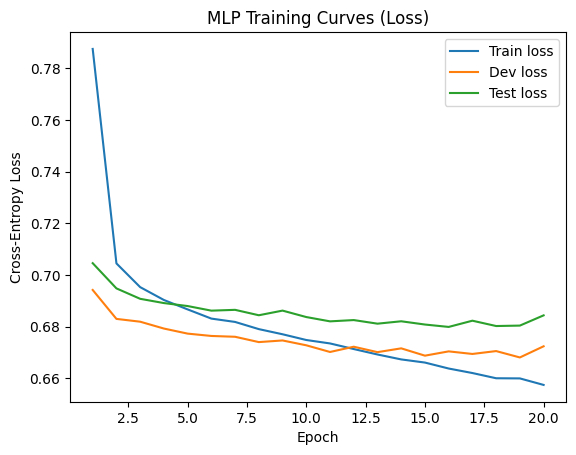

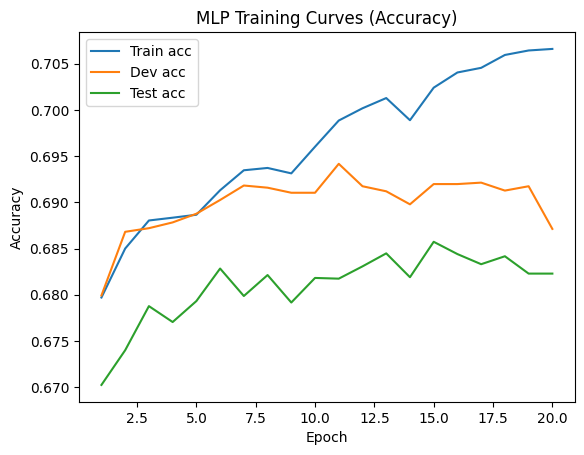

In [13]:
epochs = np.arange(1, EPOCHS + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, dev_losses, label="Dev loss")
plt.plot(epochs, test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("MLP Training Curves (Loss)")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_accs, label="Train acc")
plt.plot(epochs, dev_accs, label="Dev acc")
plt.plot(epochs, test_accs, label="Test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Training Curves (Accuracy)")
plt.legend()
plt.show()


## Final results + evaluation

Final metrics:
- Train: loss = 0.6466, acc = 0.7066
- Dev  : loss = 0.6724, acc = 0.6871
- Test : loss = 0.6844, acc = 0.6823

Next, we report the **final train accuracy** and **final test accuracy**, and compute a **7×7 confusion matrix to see which grades get confused most.


Final Train (loss, acc): (0.646558622632148, 0.7066035995236418)
Final Dev   (loss, acc): (0.6724281398984084, 0.6871232876712329)
Final Test  (loss, acc): (0.6843968623681651, 0.6822875919261462)


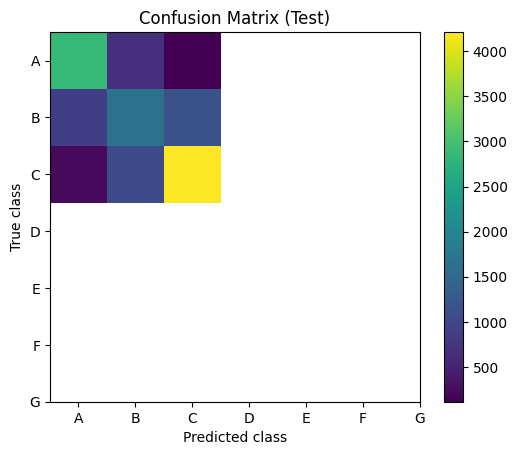

Confusion matrix:
 [[2854  683  115]
 [ 869 1655 1128]
 [ 221 1045 4212]]


In [15]:
def predict_all(model, loader):
    model.eval()
    all_preds = []
    all_true = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.append(preds)
            all_true.append(yb.numpy())
    return np.concatenate(all_true), np.concatenate(all_preds)

y_true, y_pred = predict_all(model, test_loader)

# Confusion matrix (7x7)
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

print("Final Train (loss, acc):", evaluate(model, train_loader))
print("Final Dev   (loss, acc):", evaluate(model, dev_loader))
print("Final Test  (loss, acc):", evaluate(model, test_loader))

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(range(7), list("ABCDEFG"))
plt.yticks(range(7), list("ABCDEFG"))
plt.colorbar()
plt.show()

print("Confusion matrix:\n", cm)
